## 👩‍🏫 👩🏿‍🏫 What You’ll learn
### By the end of this notebook, you will be able to:

Detect and remove duplicate entries from a dataset.
Apply appropriate strategies for handling missing values.
Perform basic feature engineering (new attributes, encoding).
Detect and handle outliers using statistical methods.
Standardize and normalize features to prepare for modeling.
Transform and encode features (e.g. Age groups) for improved model input.


Each exercise builds on the previous one — keep a consistent preprocessing narrative throughout the notebook. Also, be sure to comment your code to explain your decisions, especially when choosing thresholds or methods.



💡 Tip: The recommended preprocessing sequence is:

1. Handle duplicates
2. Address missing values
3. Treat outliers
4. Encode categorical variables


For all of the below exercises, you will use the Titanic dataset (train.csv), so load it beforehand on your notebook.
You will notice in the following exercises that the dataset is already pretty clean but try and understand all of the functions used for preprocessing the data.
Optionally, if you have time and willing to, you can redo the exercises with a less clean dataset : Weather Data Munich 1954-2022.

---
## 🌟 Exercise 1: Duplicate Detection and Removal
### Instructions
Objective: Identify and remove duplicate entries in the Titanic dataset.

- Load the Titanic dataset.
- Identify if there are any duplicate rows based on all columns.
- Remove any duplicate rows found in the dataset.
- Verify the removal of duplicates by checking the number of rows before and after the duplicate removal.

*Hint: Use the duplicated() and drop_duplicates() functions in Pandas.*

In [1]:
import pandas as pd

In [2]:
titanic_data = pd.read_csv('titanic_train.csv')
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
titanic_data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [6]:
len_df_before = len(titanic_data)

In [7]:
titanic_data.drop_duplicates(inplace=True)

In [8]:
len_df_after = len(titanic_data)

In [9]:
print(f"Length of the dataset before dropping duplicates: {len_df_before}")
print(f"Length of the dataset after dropping duplicates: {len_df_after}")

Length of the dataset before dropping duplicates: 891
Length of the dataset after dropping duplicates: 891


## 🌟 Exercise 2: Handling Missing Values
### Instructions
- Identify columns in the Titanic dataset with missing values.
- Explore different strategies for handling missing data, such as removal, imputation, and filling with a constant value.
- Apply each strategy to different columns based on the nature of the data.

*Hint: Review methods like dropna(), fillna(), and SimpleImputer from scikit-learn.*

In [10]:
from sklearn.impute import SimpleImputer

In [11]:
titanic_data.isna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
# Age: partly missing (177 / 891). Fill with median using SimpleImputer.
imputer = SimpleImputer(strategy='median')
titanic_data[['Age']] = imputer.fit_transform(titanic_data[['Age']])

In [13]:
titanic_data['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [14]:
# Cabin: Mostly missing (687 / 891). Can either remove the column entirely, or fill it with default data ('unknown' or random value from the existing ones)
titanic_data = titanic_data.drop(columns=['Cabin'])

In [15]:
# Embarked: Barely missing (2 / 891). Can fill with the mode.
titanic_data['Embarked'] = titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0])

In [16]:
titanic_data['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

## 🌟 Exercise 3: Feature Engineering
### Instructions
- Create new features, such as **Family Size** from **SibSp** and **Parch**, and **Title** extracted from the **Name** column.
- Convert categorical variables into numerical form using techniques like one-hot encoding or label encoding.
- You will encode new categorical features (like Title) here, but do not scale numerical features yet — that will come after outlier handling.

*Hint: Utilize Pandas for data manipulation and scikit-learn’s preprocessing module for encoding.*

In [17]:
titanic_data['Family Size'] = titanic_data['SibSp'] + titanic_data['Parch'] + 1 # Family Size = SibSp + Parch + 1 (the passenger)
titanic_data['Title'] = titanic_data['Name'].str.extract(r',\s*([^.]+)\.') # Title: extract from the name using regex ("Allen, Mr. William Henry = Mr")

In [18]:
titanic_data['Family Size']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: Family Size, Length: 891, dtype: int64

In [19]:
titanic_data['Title']

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 891, dtype: str

In [20]:
titanic_data['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [21]:
titanic_data['Title'] = titanic_data['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

title_counts = titanic_data['Title'].value_counts()
rare_titles = title_counts[title_counts < 10].index
titanic_data['Title'] = titanic_data['Title'].replace(rare_titles, 'Rare')

# Optional: fold near-synonyms into the main categories instead of "Rare"

titanic_data['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [22]:
titanic_data = pd.get_dummies(titanic_data, columns=['Title', 'Embarked'], drop_first=True)
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Family Size,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,2,False,True,False,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,2,False,False,True,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,1,True,False,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,2,False,False,True,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,1,False,True,False,False,False,True


In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
le = LabelEncoder()
titanic_data['Sex'] = le.fit_transform(titanic_data['Sex']) # Female = 0, Male = 1

In [25]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Family Size,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2,False,True,False,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,False,False,True,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,1,True,False,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,False,False,True,False,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,1,False,True,False,False,False,True


## 🌟 Exercise 4: Outlier Detection and Handling
### Goal: Detect and cap or transform outliers in columns like Fare and Age.

1. Visualize distributions using boxplots or histograms to identify potential outliers.
2. Use IQR or Z-score methods to detect them.
3. Handle outliers with:
    - Quantile capping (e.g. 0.98)
    - Log transformation
    - Row removal
4. Compare the dataset before and after treatment.

*📌 Note: Small differences between 0.98 and 0.99 quantiles are normal when extreme values are rare or far apart. Use df.quantile() to explore and choose thresholds empirically, backed by visualization.*

In [26]:
import matplotlib.pyplot as plt
import numpy as np

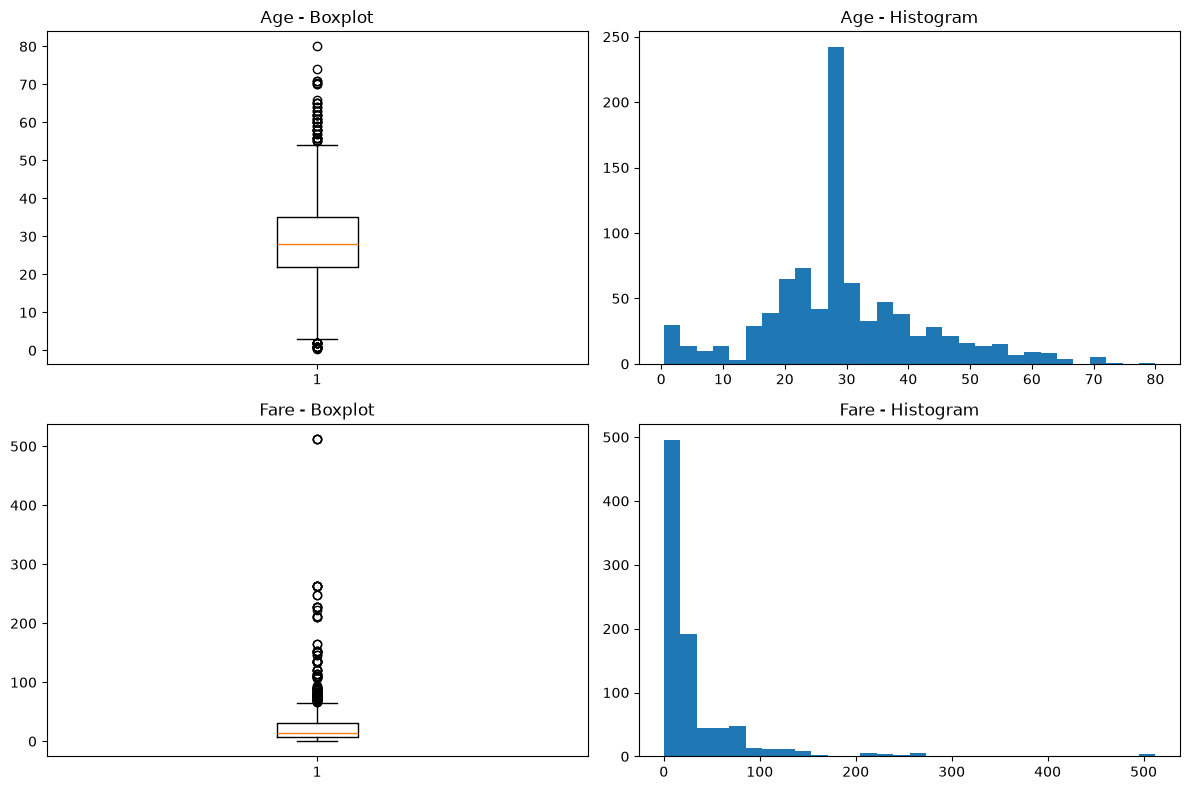

In [27]:
# Visualize the distributions with histograms and boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].boxplot(titanic_data['Age'])
axes[0, 0].set_title('Age - Boxplot')
axes[0, 1].hist(titanic_data['Age'], bins=30)
axes[0, 1].set_title('Age - Histogram')
axes[1, 0].boxplot(titanic_data['Fare'])
axes[1, 0].set_title('Fare - Boxplot')
axes[1, 1].hist(titanic_data['Fare'], bins=30)
axes[1, 1].set_title('Fare - Histogram')
plt.tight_layout()
plt.show()

In [28]:
# IQR method
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1

    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

fare_low, fare_high = iqr_bounds(titanic_data['Fare'])
fare_outliers_iqr = titanic_data[(titanic_data['Fare'] < fare_low) | (titanic_data['Fare'] > fare_high)]

print(f"Fare IQR bounds: [{fare_low:.2f}, {fare_high:.2f}] ---> {len(fare_outliers_iqr)} outliers")

age_low, age_high = iqr_bounds(titanic_data['Age'])
age_outliers_iqr = titanic_data[(titanic_data['Age'] < age_low) | (titanic_data['Age'] > age_high)]

print(f"Age IQR bounds: [{age_low:.2f}, {age_high:.2f}] ---> {len(age_outliers_iqr)} outliers")

Fare IQR bounds: [-26.72, 65.63] ---> 116 outliers
Age IQR bounds: [2.50, 54.50] ---> 66 outliers


In [29]:
# Handle outliers
# Capping
fare_cap = titanic_data['Fare'].quantile(0.98)
titanic_data['Fare_capped'] = titanic_data['Fare'].clip(upper=fare_cap)

age_cap = titanic_data['Age'].quantile(0.98)
titanic_data['Age_capped'] = titanic_data['Age'].clip(upper=age_cap)

In [30]:
# Log transformation
titanic_data['Fare_log'] = np.log1p(titanic_data['Fare'])

In [31]:
# Row removal using the IQR bounds
titanic_data_no_outliers = titanic_data[(titanic_data['Fare'] >= fare_low) & (titanic_data['Fare'] <= fare_high)]

In [32]:
print(titanic_data['Fare'].describe())
print(titanic_data['Fare_capped'].describe())
print(titanic_data['Fare_log'].describe())
print(f"Rows before: {len(titanic_data)}, after IQR row removal: {len(titanic_data_no_outliers)}")

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64
count    891.000000
mean      30.678483
std       39.904946
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      211.337500
Name: Fare_capped, dtype: float64
count    891.000000
mean       2.962246
std        0.969048
min        0.000000
25%        2.187218
50%        2.737881
75%        3.465736
max        6.240917
Name: Fare_log, dtype: float64
Rows before: 891, after IQR row removal: 775


In [33]:
print(titanic_data['Age'].describe())
print(titanic_data['Age_capped'].describe())
print(f"Rows before: {len(titanic_data)}, after IQR row removal: {len(titanic_data_no_outliers)}")

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64
count    891.000000
mean      29.258889
std       12.720003
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       62.000000
Name: Age_capped, dtype: float64
Rows before: 891, after IQR row removal: 775


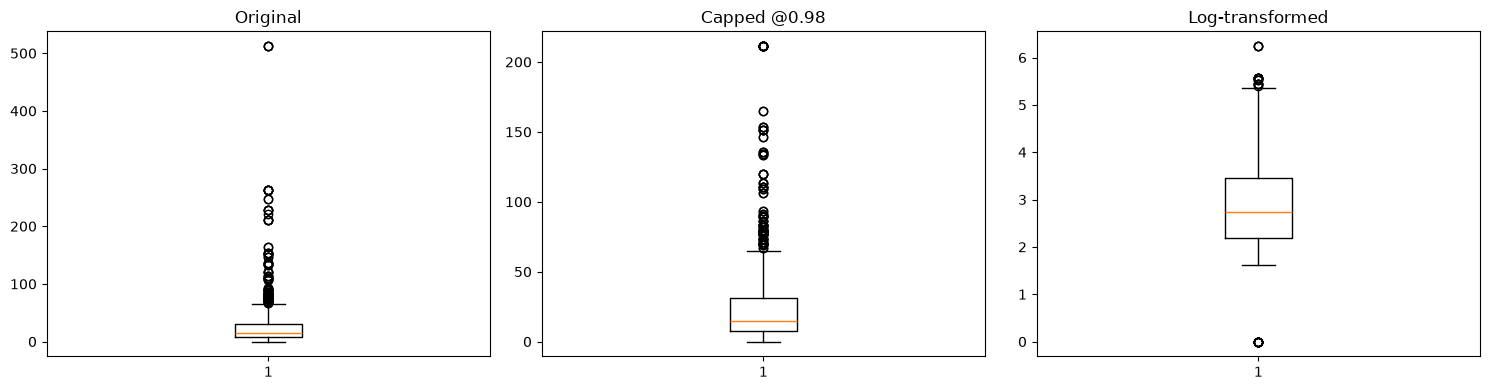

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].boxplot(titanic_data['Fare']); axes[0].set_title('Original')
axes[1].boxplot(titanic_data['Fare_capped']); axes[1].set_title('Capped @0.98')
axes[2].boxplot(titanic_data['Fare_log']); axes[2].set_title('Log-transformed')
plt.tight_layout()
plt.show()

## 🌟 Exercise 5: Data Standardization and Normalization
### Goal: Scale numerical features to prepare for modeling.

1. Use **StandardScaler** (mean = 0, std = 1) for normally distributed features.
2. Use **MinMaxScaler** (range [0, 1]) for features that are skewed or bounded.

*📌 Important: Perform this step **after outlier treatment** to avoid distortion caused by extreme values.*

In [35]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [36]:
# Age (post-capping) is reasonably symmetric (mean ~30, median ~28) — a good StandardScaler candidate
standard_scaler = StandardScaler()
titanic_data['Age_scaled'] = standard_scaler.fit_transform(titanic_data[['Age_capped']])

# Fare remains right-skewed even after capping (mean 30.7 vs median 14.5) — better suited to MinMaxScaler
minmax_scaler = MinMaxScaler()
titanic_data['Fare_scaled'] = minmax_scaler.fit_transform(titanic_data[['Fare_capped']])

In [37]:
# Compare original vs scaled distributions
print(titanic_data[['Age_capped', 'Age_scaled']].describe())
print(titanic_data[['Fare_capped', 'Fare_scaled']].describe())

       Age_capped    Age_scaled
count  891.000000  8.910000e+02
mean    29.258889  1.674680e-16
std     12.720003  1.000562e+00
min      0.420000 -2.268481e+00
25%     22.000000 -5.709877e-01
50%     28.000000 -9.902481e-02
75%     35.000000  4.515986e-01
max     62.000000  2.575432e+00
       Fare_capped  Fare_scaled
count   891.000000   891.000000
mean     30.678483     0.145163
std      39.904946     0.188821
min       0.000000     0.000000
25%       7.910400     0.037430
50%      14.454200     0.068394
75%      31.000000     0.146685
max     211.337500     1.000000


## 🌟 Exercise 6: Feature Encoding
### Goal: Finalize categorical variable encoding.

1. Identify remaining categorical columns (e.g. Sex, Embarked, Title).
2. Apply:
    - **One-Hot Encoding** for nominal variables.
    - **Label Encoding** if any ordinal variables remain.
3. Merge encoded columns back into the main dataset.

*📌 **Reminder**: Encoding comes **after** handling missing values and outliers, but **before** scaling (if applicable).*

In [38]:
# Identify what columns are still non-numeric
titanic_data.select_dtypes(include=['object', 'string']).columns

Index(['Name', 'Ticket'], dtype='str')

In [39]:
titanic_data = titanic_data.drop(columns=['Name', 'Ticket'])

In [40]:
titanic_data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Family Size      int64
Title_Miss        bool
Title_Mr          bool
Title_Mrs         bool
Title_Rare        bool
Embarked_Q        bool
Embarked_S        bool
Fare_capped    float64
Age_capped     float64
Fare_log       float64
Age_scaled     float64
Fare_scaled    float64
dtype: object

## 🌟 Exercise 7: Data Transformation for Age Feature
### Goal: Create and encode age groups.
- Use pd.cut() to create bins for life stages (e.g. child, teen, adult, senior).
- Apply one-hot encoding using pd.get_dummies().

*📌 **Example:** You might define bins like **[0, 12, 18, 60, 100]** and label them accordingly.*

In [41]:
# Bin age into different groups: child, teen, adult, senior
bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']

titanic_data['AgeGroup'] = pd.cut(titanic_data['Age'], bins=bins, labels=labels)
titanic_data['AgeGroup'].value_counts()

AgeGroup
Adult     730
Teen       70
Child      69
Senior     22
Name: count, dtype: int64

In [42]:
# One-hot encode the new AgeGroup column
titanic_data = pd.get_dummies(titanic_data, columns=['AgeGroup'], drop_first=True)
titanic_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Family Size,Title_Miss,...,Embarked_Q,Embarked_S,Fare_capped,Age_capped,Fare_log,Age_scaled,Fare_scaled,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior
0,1,0,3,1,22.0,1,0,7.2500,2,False,...,False,True,7.2500,22.0,2.110213,-0.570988,0.034305,False,True,False
1,2,1,1,0,38.0,1,0,71.2833,2,False,...,False,False,71.2833,38.0,4.280593,0.687580,0.337296,False,True,False
2,3,1,3,0,26.0,0,0,7.9250,1,True,...,False,True,7.9250,26.0,2.188856,-0.256346,0.037499,False,True,False
3,4,1,1,0,35.0,1,0,53.1000,2,False,...,False,True,53.1000,35.0,3.990834,0.451599,0.251257,False,True,False
4,5,0,3,1,35.0,0,0,8.0500,1,False,...,False,True,8.0500,35.0,2.202765,0.451599,0.038091,False,True,False
